## Imports

In [46]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns
from google.colab import userdata, drive
from sklearn.metrics import cohen_kappa_score
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Read Data

In [35]:
df_matching = pd.read_csv("/content/drive/My Drive/Mestrado/Dissertação/mimic-iv-ext-cardiac-disease/processed/matching_report.csv")

df_audit = pd.read_csv("/content/drive/My Drive/Mestrado/Dissertação/mimic-iv-ext-cardiac-disease/processed/matching_audit_results.csv")

df_replication = pd.read_csv("/content/drive/My Drive/Mestrado/Dissertação/mimic-iv-ext-cardiac-disease/processed/matching_judge.csv")

In [36]:
print("--- EXTRATO DOS DADOS ---")
print(f"Total de avaliações na Auditoria (Exp 1): {len(df_audit)}")
print(f"Total de comparações na Replicação (Exp 2): {len(df_replication)}")

--- EXTRATO DOS DADOS ---
Total de avaliações na Auditoria (Exp 1): 1676
Total de comparações na Replicação (Exp 2): 10


## Transform

In [37]:
def prepare_matching_set(df):
    # Se a coluna subject_ids veio como string de lista (ex: "[1, 2, 3]"), use ast.literal_eval.
    # Se já for uma lista do Python, pole pular essa conversão.
    import ast
    if isinstance(df['subject_ids'].iloc[0], str):
        df['subject_ids'] = df['subject_ids'].apply(ast.literal_eval)

    # "Explode" a lista para ter uma linha por paciente/estudo
    df_exploded = df.explode('subject_ids').dropna(subset=['subject_ids'])
    df_exploded['subject_ids'] = df_exploded['subject_ids'].astype(int)

    # Cria a chave única: NCT_ID + ID_DO_PACIENTE
    df_exploded['match_key'] = df_exploded['nct_id'].astype(str) + "_" + df_exploded['subject_ids'].astype(str)
    return set(df_exploded['match_key'])

# 1. Prepara os dois conjuntos de chaves
set_model1 = prepare_matching_set(df_matching)
set_model2 = prepare_matching_set(df_replication)

## Analysis

### Audit (quality of matching)

In [38]:
print("\n=== ANÁLISE 1: AUDITORIA DO MATCHING INICIAL ===")
total_audited = len(df_audit)
correct_count = df_audit['is_correct'].sum()
accuracy_rate = (correct_count / total_audited) * 100

print(f"Acurácia Global do Sistema (Concordância do Juiz): {accuracy_rate:.2f}%")

# Distribuição dos Erros (Onde o sistema errou?)
error_distribution = df_audit['error_type'].value_counts(normalize=True) * 100
print("\nDistribuição Percentual dos Erros:")
print(error_distribution)


=== ANÁLISE 1: AUDITORIA DO MATCHING INICIAL ===
Acurácia Global do Sistema (Concordância do Juiz): 18.38%

Distribuição Percentual dos Erros:
error_type
False Positive (Included ineligible)    60.233918
Missing Clinical Data                   39.766082
Name: proportion, dtype: float64


In [39]:
df_audit['justification'].head()

,justification
0,The patient has a documented pleural procedure...
1,The patient meets all inclusion criteria (age ...
2,"The patient is >18 years old, has documented n..."
3,The patient meets age and pleural effusion cri...
4,"The patient is >18 years old, has documented p..."


### Agreement between models

In [40]:
print("\n=== ANÁLISE 2: CONCORDÂNCIA ENTRE MODELOS (REPLICAÇÃO) ===")
# Calcula as métricas de Teoria de Conjuntos
intersection = set_model1.intersection(set_model2)
union = set_model1.union(set_model2)

jaccard_similarity = (len(intersection) / len(union)) * 100 if len(union) > 0 else 0
agreement_m1 = (len(intersection) / len(set_model1)) * 100 if len(set_model1) > 0 else 0
agreement_m2 = (len(intersection) / len(set_model2)) * 100 if len(set_model2) > 0 else 0

print(f"=== RESULTADOS DA COMPARAÇÃO ENTRE MODELOS ===")
print(f"Total de pares (Estudo-Paciente) no Modelo 1: {len(set_model1)}")
print(f"Total de pares (Estudo-Paciente) no Modelo 2: {len(set_model2)}")
print(f"Pares em comum (Concordância exata): {len(intersection)}")
print(f"Índice de Similaridade de Jaccard: {jaccard_similarity:.2f}%")
print(f"Quanto do Modelo 1 é compartilhado com o Modelo 2: {agreement_m1:.2f}%")
print(f"Quanto do Modelo 2 é compartilhado com o Modelo 1: {agreement_m2:.2f}%")


=== ANÁLISE 2: CONCORDÂNCIA ENTRE MODELOS (REPLICAÇÃO) ===
=== RESULTADOS DA COMPARAÇÃO ENTRE MODELOS ===
Total de pares (Estudo-Paciente) no Modelo 1: 1503
Total de pares (Estudo-Paciente) no Modelo 2: 246
Pares em comum (Concordância exata): 246
Índice de Similaridade de Jaccard: 16.37%
Quanto do Modelo 1 é compartilhado com o Modelo 2: 16.37%
Quanto do Modelo 2 é compartilhado com o Modelo 1: 100.00%


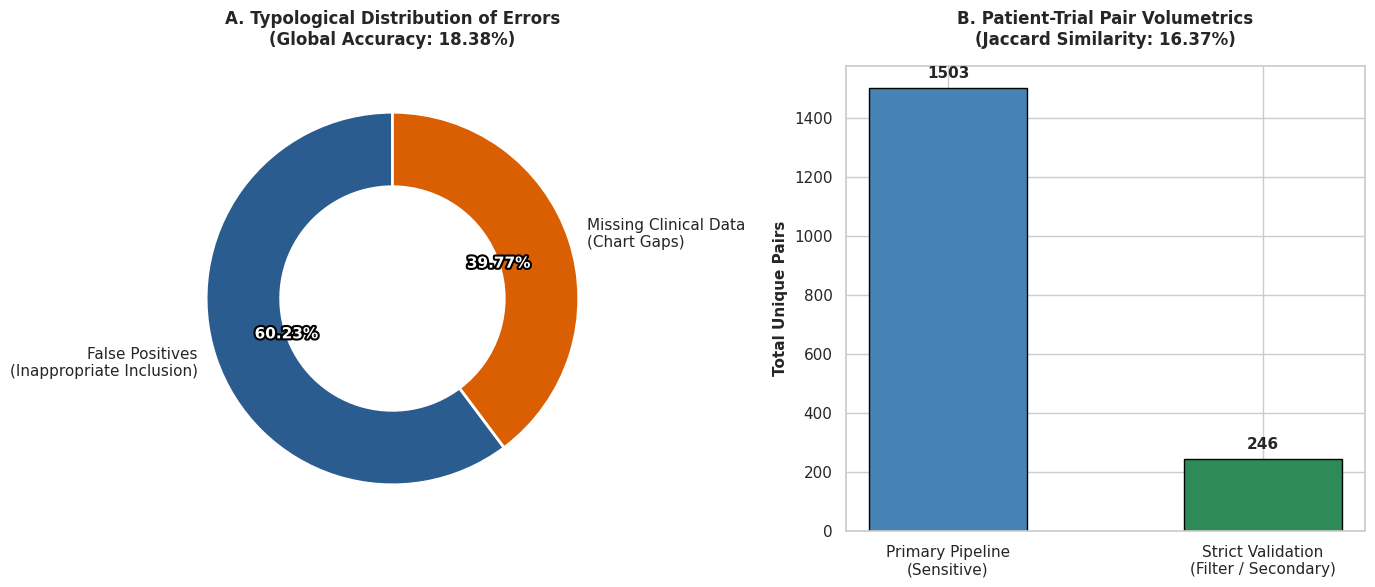

In [45]:
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11

labels_exp1 = ['False Positives\n(Inappropriate Inclusion)', 'Missing Clinical Data\n(Chart Gaps)']
sizes_exp1 = [60.23, 39.77]
colors = ['#2b5c8f', '#d95f02'] # Azul acadêmico e Laranja sobrio

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de Rosca (Donut Chart)
wedges, texts, autotexts = ax1.pie(
    sizes_exp1,
    labels=labels_exp1,
    autopct='%1.2f%%',
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor='w', linewidth=2)
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_weight('bold')
    # Adiciona um efeito de contorno (stroke) para destacar o texto sobre qualquer cor
    autotext.set_path_effects([
        pe.withStroke(linewidth=3, foreground='black')
    ])

ax1.set_title('A. Typological Distribution of Errors\n(Global Accuracy: 18.38%)', fontsize=12, pad=15, fontweight='bold')
categories = ['Primary Pipeline\n(Sensitive)', 'Strict Validation\n(Filter / Secondary)']
values = [1503, 246]
bar_colors = ['#4682B4', '#2E8B57'] # Azul aço e Verde marinho

bars = ax2.bar(categories, values, color=bar_colors, width=0.5, edgecolor='black', linewidth=1)
ax2.set_title('B. Patient-Trial Pair Volumetrics\n(Jaccard Similarity: 16.37%)', fontsize=12, pad=15, fontweight='bold')
ax2.set_ylabel('Total Unique Pairs', fontsize=11, fontweight='bold')

# Adiciona os valores exatos em cima de cada barra
for bar in bars:
    height = bar.get_height()
    ax2.annotate(f'{height}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),  # 5 pontos de desvio vertical
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Ajustes gerais de layout
plt.tight_layout()

plt.show()